# 01. Data Exploration
In this notebook, we will explore the data and the different bands before we start training our model.

### Imports and Inspection of Dataset

In [1]:
from datasets import load_dataset
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

/Users/david/eurosat/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
EuroSAT_RGB = load_dataset("blanchon/EuroSAT_RGB")
print(EuroSAT_RGB)

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 16200
    })
    test: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
    validation: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
})


As we see from the output this dataset is pre-split into train, test and validation sets. The train set is used to train the model, the test set to evaluate the model and the validation set to tune the hyperparameters.

Now lets identify the distribution of the 10 classes this dataset contains. We start by getting the labels from the train split and then plotting each class to a bar in our chart.

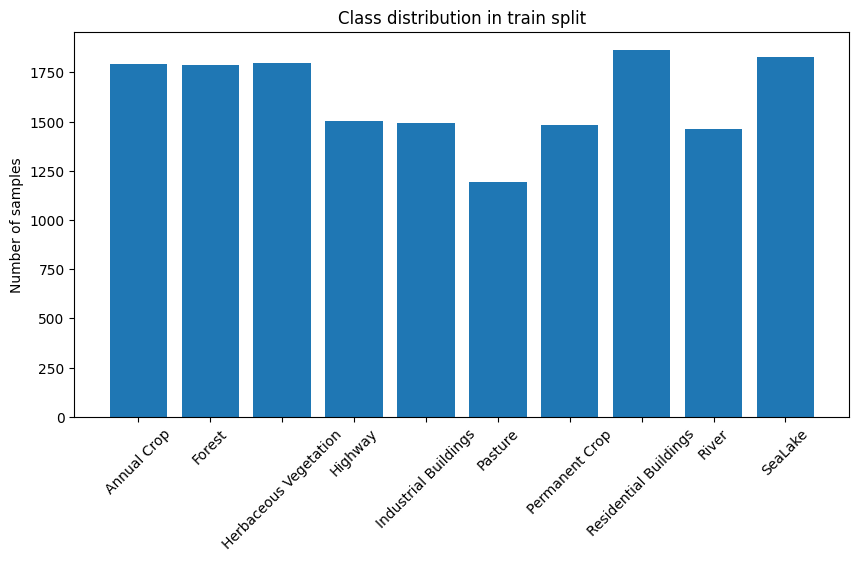

In [7]:
labels = EuroSAT_RGB["train"]["label"]
counts = Counter(labels)

label_names = EuroSAT_RGB["train"].features["label"].names
plt.figure(figsize=(10, 5))
plt.bar([label_names[i] for i in sorted(counts.keys())], [counts[i] for i in sorted(counts.keys())])
plt.ylabel("Number of samples")
plt.title("Class distribution in train split")
plt.xticks(rotation=45)
plt.show()

According to this bar-chart, we see that out of the 10 classes; Pasture is the least represented class, followed by Highway, Industrial building, Permanent Crop, and River. But it should not cause any problems since we have still have a lot of data for these classes (1250 - 1500 samples).

It seems to me that the data is roughly balanced, meaning we don't need to apply any weighting or oversampling techniques.

Next let's take a look at some sample images to get a better understanding of what the CNN model is going to be trained on. I will first try to load the images in a grid representing each class.

Filter: 100%|██████████| 16200/16200 [00:01<00:00, 12660.80 examples/s]


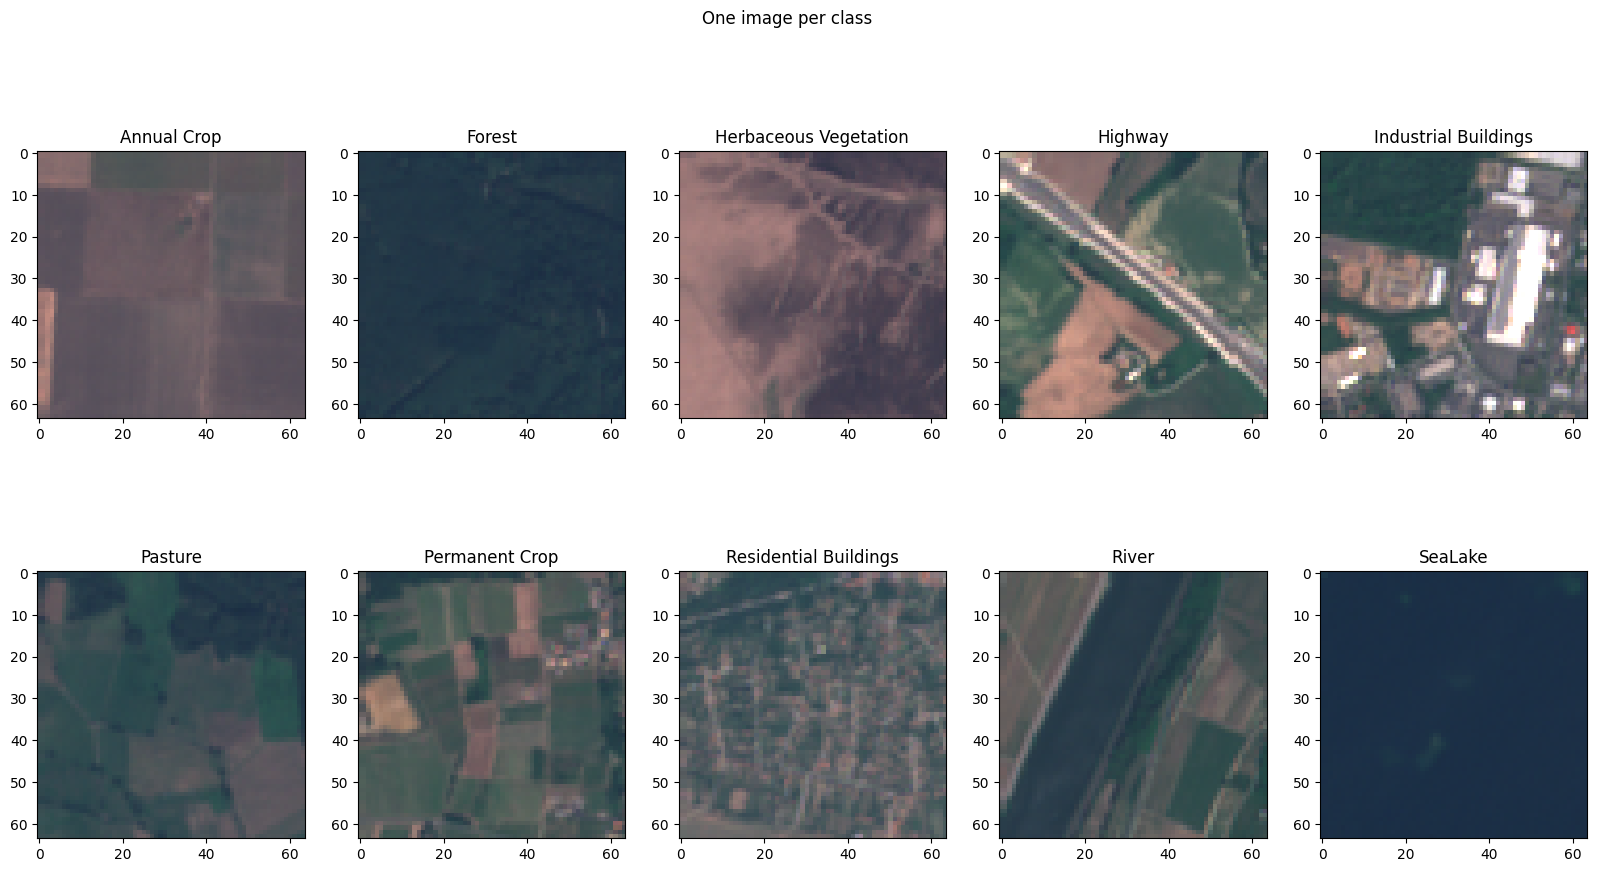

In [ ]:
fig, axis = plt.subplots(2, 5, figsize=(20, 10))

for i, ax in enumerate(axis.flat):
    sample = EuroSAT_RGB["train"].filter(lambda x: x["label"] == i)[0]
    ax.imshow(sample["image"])
    ax.set_title(label_names[i])

plt.suptitle("Grid showing one image from each class")
plt.show()


I notice since i didnt turn of the axis with `ax.axis("off")` that we see X-axis and Y-axis on the images, and it seems it is acutally showing 0-64 for both the X and Y axis, confirmign that he images are indeed 64x64 pixels.

From the grid we can see one image from each land cover class. In my opinion, i think the Forest-image and SeaLake-image looks quite similar, this goes for Pasture and PermanentCrop also, i am not sure how the CNN model would be able to accuratly tell these classes apart.